# Visa Certification: Model Building and Final Selection

## Model Evaluation Criterion

A model can make two critical mistakes:
1. Predicting **Certified** when the actual outcome is **Denied**.
2. Predicting **Denied** when the actual outcome is **Certified**.

Both errors are important for this use case. To balance false positives and false negatives, we prioritize **F1 score** as the main evaluation metric.

We also use **balanced class weights** in tree-based models so both classes get fair attention during training.

In [15]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import metrics
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
)
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

try:
    from xgboost import XGBClassifier

    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("xgboost is not installed. XGBoost sections will be skipped.")

## Load Feature Engineered Data

In [16]:
default_path = Path(r"C:\Users\aniru\globel\global-mobility-analyzer\dataset\feature_engineered_data.csv")

if default_path.exists():
    dataset_path = default_path
else:
    project_root = Path.cwd().resolve().parent
    dataset_path = project_root / "dataset" / "feature_engineered_data.csv"

df = pd.read_csv(dataset_path)
print(f"Loaded dataset from: {dataset_path}")
print(f"Shape: {df.shape}")
df.head()

Loaded dataset from: C:\Users\aniru\globel\global-mobility-analyzer\dataset\feature_engineered_data.csv
Shape: (25480, 11)


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,0
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,1
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,0
3,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,0
4,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,1


## Split Data and Prepare Features

In [17]:
target_col = "case_status"
if target_col not in df.columns:
    raise ValueError(f"Expected target column '{target_col}' not found in dataset")

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

if y.dtype == object:
    y_mapped = y.astype(str).str.strip().str.lower().map({"certified": 1, "denied": 0})
    if y_mapped.isna().any():
        raise ValueError("Target contains unexpected labels. Expected 'Certified' or 'Denied'.")
    y = y_mapped

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print("Class distribution in train set:")
print(y_train.value_counts(normalize=True))

X_train: (20384, 21), X_test: (5096, 21)
Class distribution in train set:
case_status
1    0.667877
0    0.332123
Name: proportion, dtype: float64


## Evaluation Criterion and Helper Functions

In [18]:
def model_performance_classification_sklearn(model, predictors, target):
    """
    Compute core classification metrics for a fitted sklearn model.

    model: trained classifier
    predictors: independent variables
    target: dependent variable
    """

    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred)
    precision = precision_score(target, pred)
    f1 = f1_score(target, pred)

    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf


def confusion_matrix_sklearn(model, predictors, target):
    """
    Plot confusion matrix with absolute counts and percentages.

    model: trained classifier
    predictors: independent variables
    target: dependent variable
    """

    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)

    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.title("Confusion Matrix")
    plt.show()

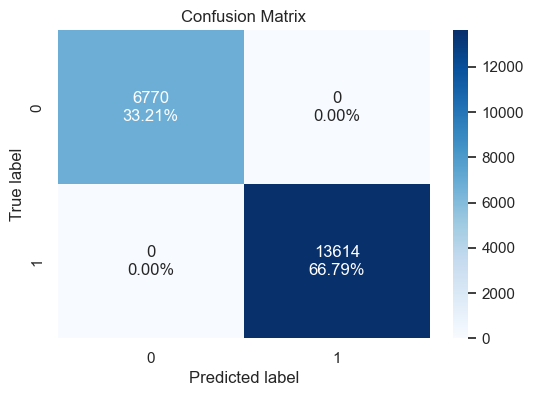

Decision Tree - Train Performance


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


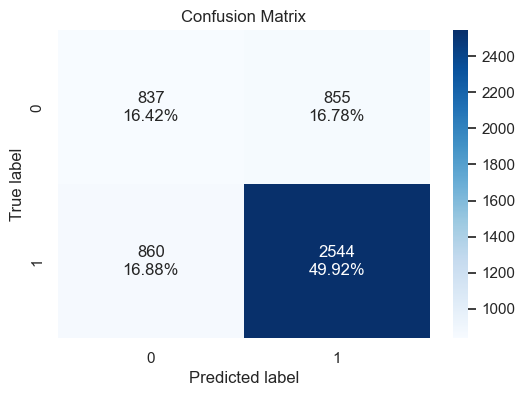

Decision Tree - Test Performance


,Accuracy,Recall,Precision,F1
0,0.663462,0.747356,0.748455,0.747905


Observation: Baseline decision tree is usually overfitting (very high train score vs lower test score).


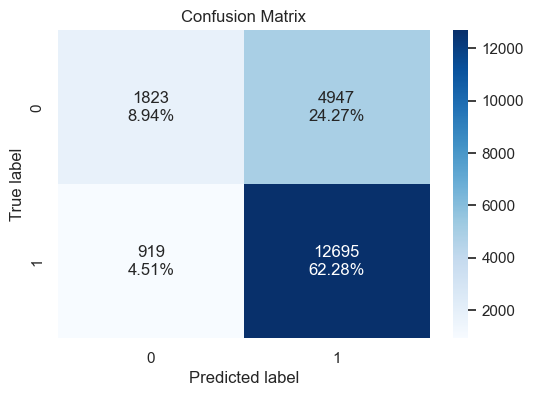

Tuned Decision Tree - Train Performance


,Accuracy,Recall,Precision,F1
0,0.712225,0.932496,0.71959,0.812324


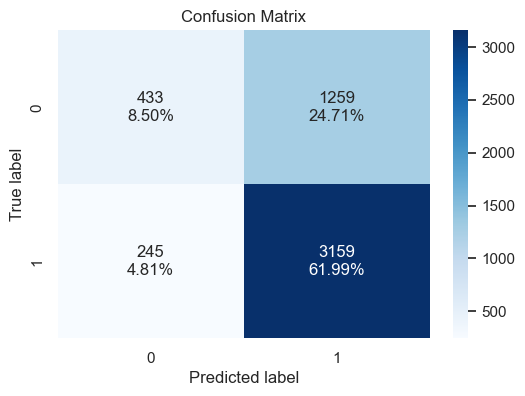

Tuned Decision Tree - Test Performance


,Accuracy,Recall,Precision,F1
0,0.704867,0.928026,0.715029,0.807722


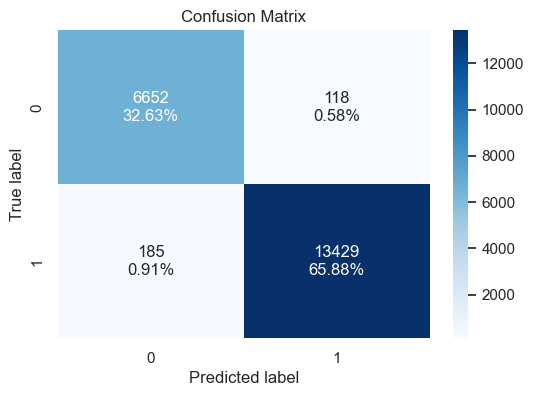

Bagging Classifier - Train Performance


,Accuracy,Recall,Precision,F1
0,0.985135,0.986411,0.99129,0.988844


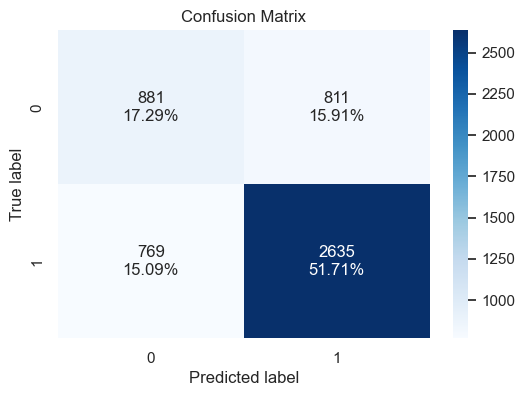

Bagging Classifier - Test Performance


,Accuracy,Recall,Precision,F1
0,0.689953,0.774089,0.764655,0.769343


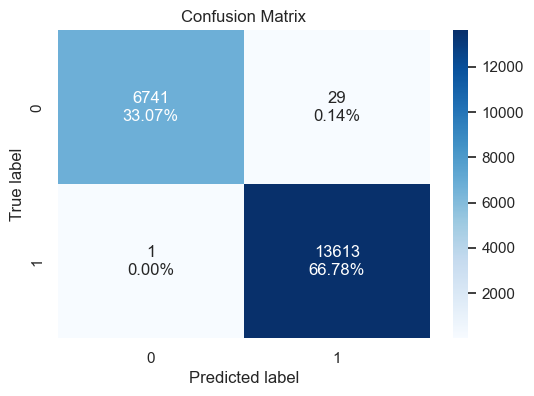

Tuned Bagging Classifier - Train Performance


,Accuracy,Recall,Precision,F1
0,0.998528,0.999927,0.997874,0.998899


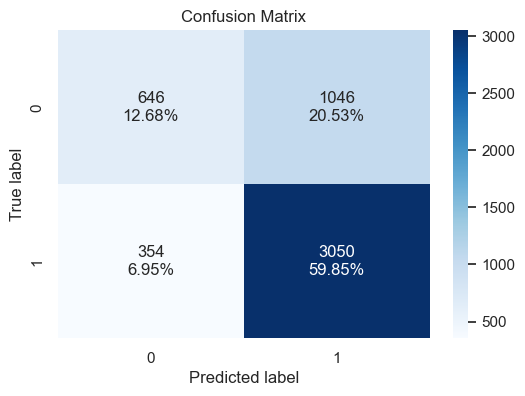

Tuned Bagging Classifier - Test Performance


,Accuracy,Recall,Precision,F1
0,0.725275,0.896005,0.744629,0.813333


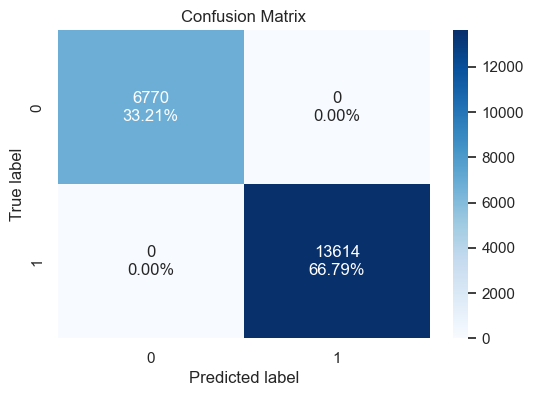

Random Forest - Train Performance


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


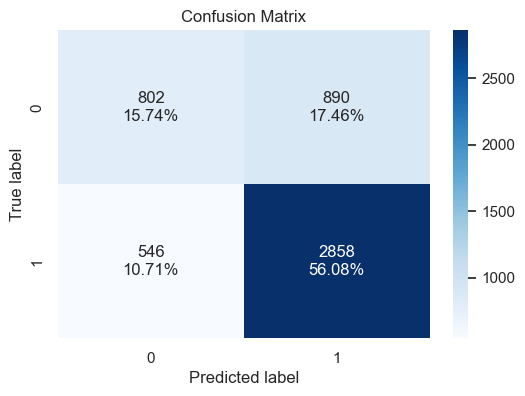

Random Forest - Test Performance


,Accuracy,Recall,Precision,F1
0,0.71821,0.8396,0.76254,0.799217


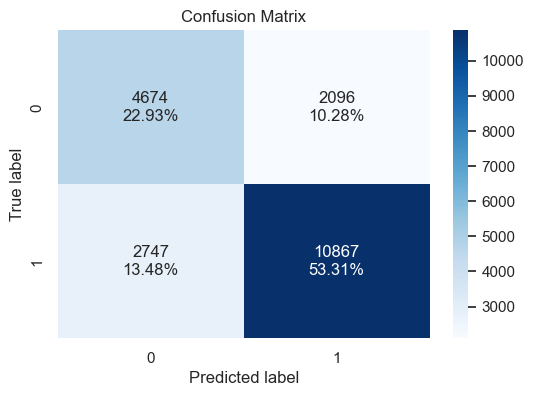

Tuned Random Forest - Train Performance


,Accuracy,Recall,Precision,F1
0,0.762412,0.798222,0.838309,0.817775


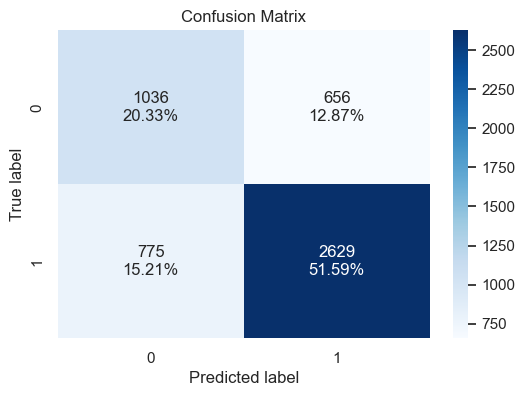

Tuned Random Forest - Test Performance


,Accuracy,Recall,Precision,F1
0,0.719192,0.772327,0.800304,0.786067


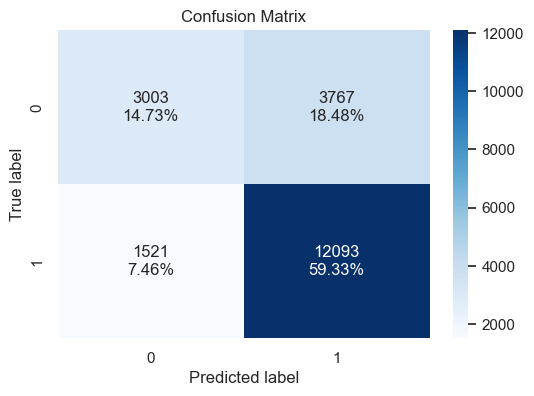

AdaBoost - Train Performance


,Accuracy,Recall,Precision,F1
0,0.740581,0.888277,0.762484,0.820588


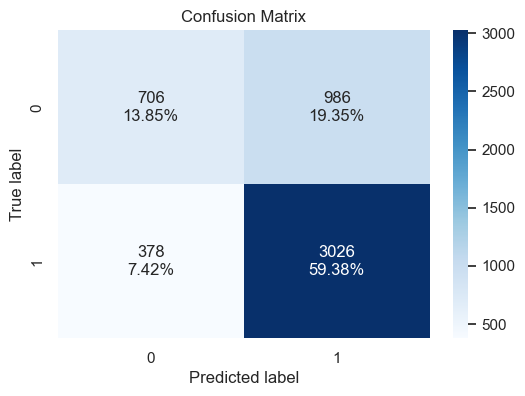

AdaBoost - Test Performance


,Accuracy,Recall,Precision,F1
0,0.732339,0.888954,0.754237,0.816073


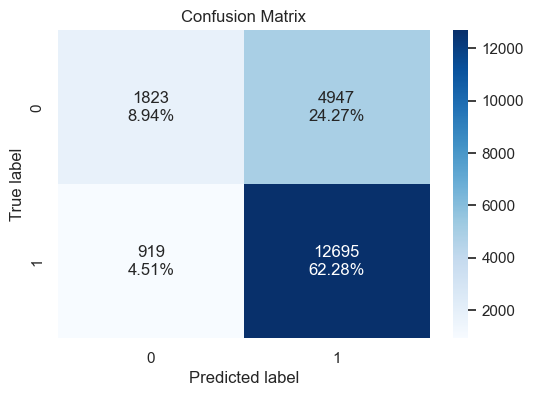

Tuned AdaBoost - Train Performance


,Accuracy,Recall,Precision,F1
0,0.712225,0.932496,0.71959,0.812324


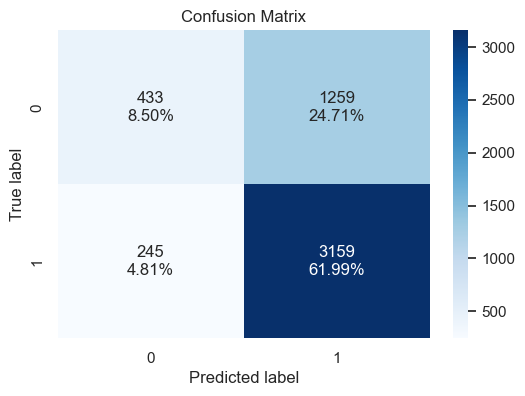

Tuned AdaBoost - Test Performance


,Accuracy,Recall,Precision,F1
0,0.704867,0.928026,0.715029,0.807722


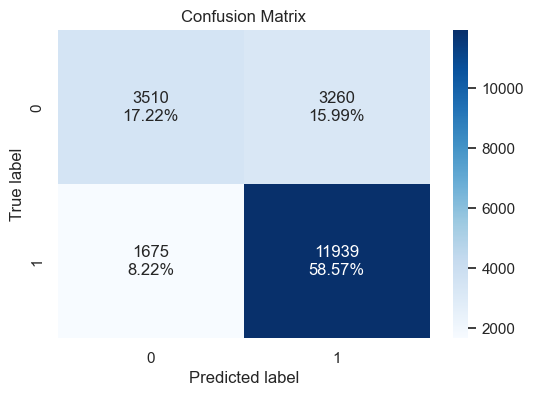

Gradient Boosting - Train Performance


,Accuracy,Recall,Precision,F1
0,0.757898,0.876965,0.785512,0.828723


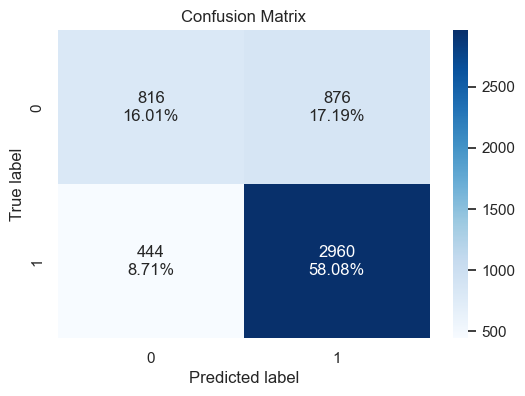

Gradient Boosting - Test Performance


,Accuracy,Recall,Precision,F1
0,0.740973,0.869565,0.771637,0.81768


In [ ]:
# -------------------------------
# Decision Tree - Baseline Model
# -------------------------------
model = DecisionTreeClassifier(random_state=1)
model.fit(X_train, y_train)

confusion_matrix_sklearn(model, X_train, y_train)
decision_tree_perf_train = model_performance_classification_sklearn(model, X_train, y_train)
print("Decision Tree - Train Performance")
display(decision_tree_perf_train)

confusion_matrix_sklearn(model, X_test, y_test)
decision_tree_perf_test = model_performance_classification_sklearn(model, X_test, y_test)
print("Decision Tree - Test Performance")
display(decision_tree_perf_test)

print("Observation: Baseline decision tree is usually overfitting (very high train score vs lower test score).")


# ----------------------------------------------
# Hyperparameter Tuning - Decision Tree Classifier
# ----------------------------------------------
dtree_estimator = DecisionTreeClassifier(class_weight="balanced", random_state=1)

parameters = {
    "max_depth": np.arange(10, 30, 5),
    "min_samples_leaf": [3, 5, 7],
    "max_leaf_nodes": [2, 3, 5],
    "min_impurity_decrease": [0.0001, 0.001],
}

scorer = metrics.make_scorer(metrics.f1_score)
grid_obj = GridSearchCV(dtree_estimator, parameters, scoring=scorer, n_jobs=-1, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

dtree_estimator = grid_obj.best_estimator_
dtree_estimator.fit(X_train, y_train)

confusion_matrix_sklearn(dtree_estimator, X_train, y_train)
dtree_estimator_model_train_perf = model_performance_classification_sklearn(dtree_estimator, X_train, y_train)
print("Tuned Decision Tree - Train Performance")
display(dtree_estimator_model_train_perf)

confusion_matrix_sklearn(dtree_estimator, X_test, y_test)
dtree_estimator_model_test_perf = model_performance_classification_sklearn(dtree_estimator, X_test, y_test)
print("Tuned Decision Tree - Test Performance")
display(dtree_estimator_model_test_perf)


# -------------------------------------
# Bagging - Baseline and Hyperparameter Tuning
# -------------------------------------
bagging_classifier = BaggingClassifier(random_state=1)
bagging_classifier.fit(X_train, y_train)

confusion_matrix_sklearn(bagging_classifier, X_train, y_train)
bagging_classifier_model_train_perf = model_performance_classification_sklearn(bagging_classifier, X_train, y_train)
print("Bagging Classifier - Train Performance")
display(bagging_classifier_model_train_perf)

confusion_matrix_sklearn(bagging_classifier, X_test, y_test)
bagging_classifier_model_test_perf = model_performance_classification_sklearn(bagging_classifier, X_test, y_test)
print("Bagging Classifier - Test Performance")
display(bagging_classifier_model_test_perf)

bagging_estimator_tuned = BaggingClassifier(random_state=1)
parameters = {
    "max_samples": [0.7, 0.8, 0.9],
    "max_features": [0.7, 0.8, 0.9],
    "n_estimators": np.arange(90, 120, 10),
}

acc_scorer = metrics.make_scorer(metrics.f1_score)
grid_obj = GridSearchCV(bagging_estimator_tuned, parameters, scoring=acc_scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

bagging_estimator_tuned = grid_obj.best_estimator_
bagging_estimator_tuned.fit(X_train, y_train)

confusion_matrix_sklearn(bagging_estimator_tuned, X_train, y_train)
bagging_estimator_tuned_model_train_perf = model_performance_classification_sklearn(
    bagging_estimator_tuned, X_train, y_train
)
print("Tuned Bagging Classifier - Train Performance")
display(bagging_estimator_tuned_model_train_perf)

confusion_matrix_sklearn(bagging_estimator_tuned, X_test, y_test)
bagging_estimator_tuned_model_test_perf = model_performance_classification_sklearn(
    bagging_estimator_tuned, X_test, y_test
)
print("Tuned Bagging Classifier - Test Performance")
display(bagging_estimator_tuned_model_test_perf)


# --------------------------------------
# Random Forest - Baseline and Hyperparameter Tuning
# --------------------------------------
rf_estimator = RandomForestClassifier(random_state=1, class_weight="balanced")
rf_estimator.fit(X_train, y_train)

confusion_matrix_sklearn(rf_estimator, X_train, y_train)
rf_estimator_model_train_perf = model_performance_classification_sklearn(rf_estimator, X_train, y_train)
print("Random Forest - Train Performance")
display(rf_estimator_model_train_perf)

confusion_matrix_sklearn(rf_estimator, X_test, y_test)
rf_estimator_model_test_perf = model_performance_classification_sklearn(rf_estimator, X_test, y_test)
print("Random Forest - Test Performance")
display(rf_estimator_model_test_perf)

rf_tuned = RandomForestClassifier(random_state=1, bootstrap=True, class_weight="balanced")
parameters = {
    "max_depth": list(np.arange(5, 15, 5)),
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [3, 5, 7],
    "n_estimators": np.arange(50, 110, 20),
}

grid_obj = GridSearchCV(rf_tuned, parameters, scoring=acc_scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

rf_tuned = grid_obj.best_estimator_
rf_tuned.fit(X_train, y_train)

confusion_matrix_sklearn(rf_tuned, X_train, y_train)
rf_tuned_model_train_perf = model_performance_classification_sklearn(rf_tuned, X_train, y_train)
print("Tuned Random Forest - Train Performance")
display(rf_tuned_model_train_perf)

confusion_matrix_sklearn(rf_tuned, X_test, y_test)
rf_tuned_model_test_perf = model_performance_classification_sklearn(rf_tuned, X_test, y_test)
print("Tuned Random Forest - Test Performance")
display(rf_tuned_model_test_perf)


# --------------------------------------
# AdaBoost - Baseline and Hyperparameter Tuning
# --------------------------------------
ab_classifier = AdaBoostClassifier(random_state=1)
ab_classifier.fit(X_train, y_train)

confusion_matrix_sklearn(ab_classifier, X_train, y_train)
ab_classifier_model_train_perf = model_performance_classification_sklearn(ab_classifier, X_train, y_train)
print("AdaBoost - Train Performance")
display(ab_classifier_model_train_perf)

confusion_matrix_sklearn(ab_classifier, X_test, y_test)
ab_classifier_model_test_perf = model_performance_classification_sklearn(ab_classifier, X_test, y_test)
print("AdaBoost - Test Performance")
display(ab_classifier_model_test_perf)

abc_tuned = AdaBoostClassifier(random_state=1)
ada_param_name = "estimator" if "estimator" in AdaBoostClassifier().get_params() else "base_estimator"
parameters = {
    ada_param_name: [
        DecisionTreeClassifier(max_depth=1, class_weight="balanced", random_state=1),
        DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=1),
        DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=1),
    ],
    "n_estimators": np.arange(60, 100, 10),
    "learning_rate": np.arange(0.1, 0.4, 0.1),
}

grid_obj = GridSearchCV(abc_tuned, parameters, scoring=acc_scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

abc_tuned = grid_obj.best_estimator_
abc_tuned.fit(X_train, y_train)

confusion_matrix_sklearn(abc_tuned, X_train, y_train)
abc_tuned_model_train_perf = model_performance_classification_sklearn(abc_tuned, X_train, y_train)
print("Tuned AdaBoost - Train Performance")
display(abc_tuned_model_train_perf)

confusion_matrix_sklearn(abc_tuned, X_test, y_test)
abc_tuned_model_test_perf = model_performance_classification_sklearn(abc_tuned, X_test, y_test)
print("Tuned AdaBoost - Test Performance")
display(abc_tuned_model_test_perf)


# --------------------------------------
# Gradient Boosting - Baseline and Hyperparameter Tuning
# --------------------------------------
gb_classifier = GradientBoostingClassifier(random_state=1)
gb_classifier.fit(X_train, y_train)

confusion_matrix_sklearn(gb_classifier, X_train, y_train)
gb_classifier_model_train_perf = model_performance_classification_sklearn(gb_classifier, X_train, y_train)
print("Gradient Boosting - Train Performance")
display(gb_classifier_model_train_perf)

confusion_matrix_sklearn(gb_classifier, X_test, y_test)
gb_classifier_model_test_perf = model_performance_classification_sklearn(gb_classifier, X_test, y_test)
print("Gradient Boosting - Test Performance")
display(gb_classifier_model_test_perf)

gbc_tuned = GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1), random_state=1)
parameters = {
    "n_estimators": [200, 250, 300],
    "subsample": [0.8, 0.9, 1],
    "max_features": [0.7, 0.8, 0.9, 1],
    "learning_rate": np.arange(0.1, 0.4, 0.1),
}

grid_obj = GridSearchCV(gbc_tuned, parameters, scoring=acc_scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

gbc_tuned = grid_obj.best_estimator_
gbc_tuned.fit(X_train, y_train)

confusion_matrix_sklearn(gbc_tuned, X_train, y_train)
gbc_tuned_model_train_perf = model_performance_classification_sklearn(gbc_tuned, X_train, y_train)
print("Tuned Gradient Boosting - Train Performance")
display(gbc_tuned_model_train_perf)

confusion_matrix_sklearn(gbc_tuned, X_test, y_test)
gbc_tuned_model_test_perf = model_performance_classification_sklearn(gbc_tuned, X_test, y_test)
print("Tuned Gradient Boosting - Test Performance")
display(gbc_tuned_model_test_perf)


# --------------------------------------
# XGBoost - Baseline and Hyperparameter Tuning
# --------------------------------------
if XGB_AVAILABLE:
    xgb_classifier = XGBClassifier(random_state=1, eval_metric="logloss")
    xgb_classifier.fit(X_train, y_train)

    confusion_matrix_sklearn(xgb_classifier, X_train, y_train)
    xgb_classifier_model_train_perf = model_performance_classification_sklearn(
        xgb_classifier, X_train, y_train
    )
    print("XGBoost - Train Performance")
    display(xgb_classifier_model_train_perf)

    confusion_matrix_sklearn(xgb_classifier, X_test, y_test)
    xgb_classifier_model_test_perf = model_performance_classification_sklearn(
        xgb_classifier, X_test, y_test
    )
    print("XGBoost - Test Performance")
    display(xgb_classifier_model_test_perf)

    xgb_tuned = XGBClassifier(random_state=1, eval_metric="logloss")
    parameters = {
        "n_estimators": np.arange(150, 250, 50),
        "scale_pos_weight": [1, 2],
        "subsample": [0.9, 1],
        "learning_rate": np.arange(0.1, 0.21, 0.1),
        "gamma": [3, 5],
        "colsample_bytree": [0.8, 0.9],
        "colsample_bylevel": [0.9, 1],
    }

    grid_obj = GridSearchCV(xgb_tuned, parameters, scoring=acc_scorer, cv=5, n_jobs=-1)
    grid_obj = grid_obj.fit(X_train, y_train)

    xgb_tuned = grid_obj.best_estimator_
    xgb_tuned.fit(X_train, y_train)

    confusion_matrix_sklearn(xgb_tuned, X_train, y_train)
    xgb_tuned_model_train_perf = model_performance_classification_sklearn(xgb_tuned, X_train, y_train)
    print("Tuned XGBoost - Train Performance")
    display(xgb_tuned_model_train_perf)

    confusion_matrix_sklearn(xgb_tuned, X_test, y_test)
    xgb_tuned_model_test_perf = model_performance_classification_sklearn(xgb_tuned, X_test, y_test)
    print("Tuned XGBoost - Test Performance")
    display(xgb_tuned_model_test_perf)
else:
    print("xgboost package is not installed, so XGBoost sections are skipped.")
    xgb_classifier_model_train_perf = pd.DataFrame({"Accuracy": [np.nan], "Recall": [np.nan], "Precision": [np.nan], "F1": [np.nan]})
    xgb_classifier_model_test_perf = pd.DataFrame({"Accuracy": [np.nan], "Recall": [np.nan], "Precision": [np.nan], "F1": [np.nan]})
    xgb_tuned_model_train_perf = pd.DataFrame({"Accuracy": [np.nan], "Recall": [np.nan], "Precision": [np.nan], "F1": [np.nan]})
    xgb_tuned_model_test_perf = pd.DataFrame({"Accuracy": [np.nan], "Recall": [np.nan], "Precision": [np.nan], "F1": [np.nan]})
    xgb_tuned = None


# --------------------------------------
# Stacking Classifier
# --------------------------------------
estimators = [
    ("AdaBoost", ab_classifier),
    ("Gradient Boosting", gbc_tuned),
    ("Random Forest", rf_tuned),
]

final_estimator = xgb_tuned if xgb_tuned is not None else rf_tuned

stacking_classifier = StackingClassifier(estimators=estimators, final_estimator=final_estimator)
stacking_classifier.fit(X_train, y_train)

confusion_matrix_sklearn(stacking_classifier, X_train, y_train)
stacking_classifier_model_train_perf = model_performance_classification_sklearn(
    stacking_classifier, X_train, y_train
)
print("Stacking Classifier - Train Performance")
display(stacking_classifier_model_train_perf)

confusion_matrix_sklearn(stacking_classifier, X_test, y_test)
stacking_classifier_model_test_perf = model_performance_classification_sklearn(
    stacking_classifier, X_test, y_test
)
print("Stacking Classifier - Test Performance")
display(stacking_classifier_model_test_perf)


# --------------------------------------
# Model Comparison and Final Selection
# --------------------------------------
models_train_comp_df = pd.concat(
    [
        decision_tree_perf_train.T,
        dtree_estimator_model_train_perf.T,
        bagging_classifier_model_train_perf.T,
        bagging_estimator_tuned_model_train_perf.T,
        rf_estimator_model_train_perf.T,
        rf_tuned_model_train_perf.T,
        ab_classifier_model_train_perf.T,
        abc_tuned_model_train_perf.T,
        gb_classifier_model_train_perf.T,
        gbc_tuned_model_train_perf.T,
        xgb_classifier_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
        stacking_classifier_model_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree",
    "Tuned Decision Tree",
    "Bagging Classifier",
    "Tuned Bagging Classifier",
    "Random Forest",
    "Tuned Random Forest",
    "Adaboost Classifier",
    "Tuned Adaboost Classifier",
    "Gradient Boost Classifier",
    "Tuned Gradient Boost Classifier",
    "XGBoost Classifier",
    "XGBoost Classifier Tuned",
    "Stacking Classifier",
]

print("Training performance comparison:")
display(models_train_comp_df)

models_test_comp_df = pd.concat(
    [
        decision_tree_perf_test.T,
        dtree_estimator_model_test_perf.T,
        bagging_classifier_model_test_perf.T,
        bagging_estimator_tuned_model_test_perf.T,
        rf_estimator_model_test_perf.T,
        rf_tuned_model_test_perf.T,
        ab_classifier_model_test_perf.T,
        abc_tuned_model_test_perf.T,
        gb_classifier_model_test_perf.T,
        gbc_tuned_model_test_perf.T,
        xgb_classifier_model_test_perf.T,
        xgb_tuned_model_test_perf.T,
        stacking_classifier_model_test_perf.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree",
    "Tuned Decision Tree",
    "Bagging Classifier",
    "Tuned Bagging Classifier",
    "Random Forest",
    "Tuned Random Forest",
    "Adaboost Classifier",
    "Tuned Adaboost Classifier",
    "Gradient Boost Classifier",
    "Tuned Gradient Boost Classifier",
    "XGBoost Classifier",
    "XGBoost Classifier Tuned",
    "Stacking Classifier",
]

print("Testing performance comparison:")
display(models_test_comp_df)

print("Final selection: Tuned Random Forest")
final_model = rf_tuned
print("Tuned Random Forest - Test Metrics")
display(rf_tuned_model_test_perf)

confusion_matrix_sklearn(final_model, X_test, y_test)

## Important Features of Final Model

,feature,importance
0,prevailing_wage,0.181812
1,no_of_employees,0.142762
2,education_of_employee_High School,0.135929
3,yr_of_estab,0.123097
4,has_job_experience_Y,0.096748
5,education_of_employee_Master's,0.068856
6,education_of_employee_Doctorate,0.038433
7,unit_of_wage_Year,0.037396
8,continent_Europe,0.030277
9,region_of_employment_Midwest,0.021562


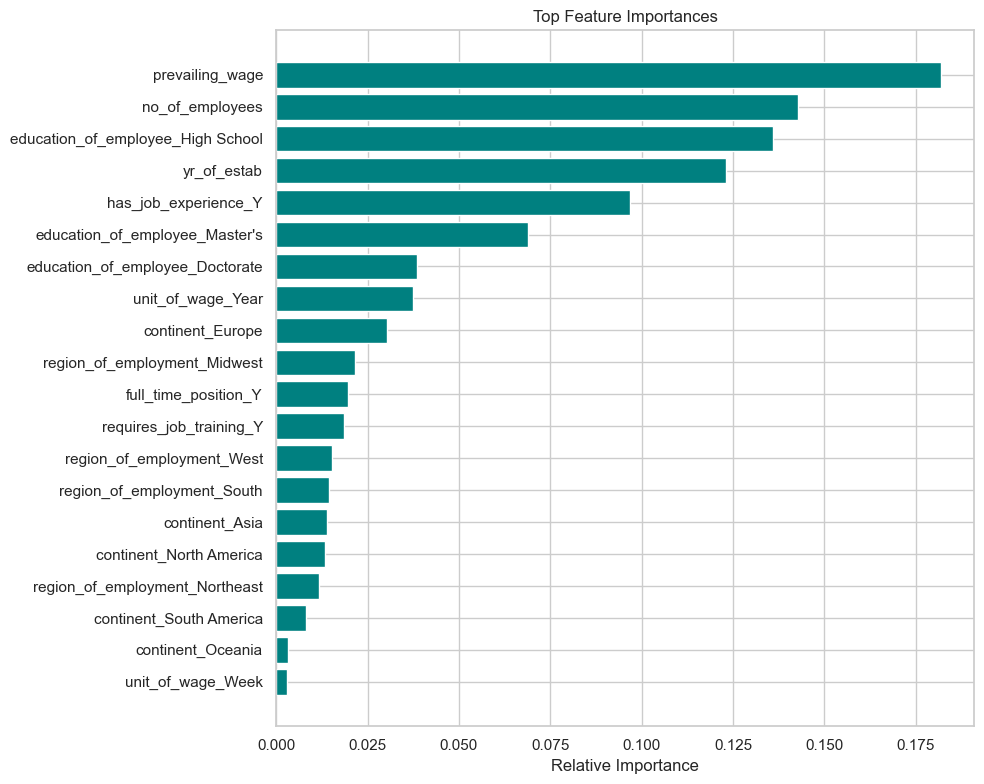

In [ ]:
feature_names = X_train.columns
importances = rf_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Actionable Insights and Recommendations

### Profiles with Higher Chance of Certification
- Education: Bachelor's degree or above, with Master's and Doctorate showing stronger outcomes.
- Job experience: Prior job experience improves the probability of certification.
- Prevailing wage: Certified cases generally show higher wage levels than denied cases.
- Unit of wage: Yearly wage applications show better certification patterns.

### Profiles with Higher Chance of Denial
- Education: High School or below.
- Job experience: No prior experience.
- Lower prevailing wages and hourly wage structure are often associated with denials.

### Practical Recommendation
- Use this model as a decision-support system, not as the only decision maker.
- Continue collecting richer employer and employee attributes (industry, specialization, years of experience, offered wage details) to improve model quality and fairness over time.